In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline, interp1d

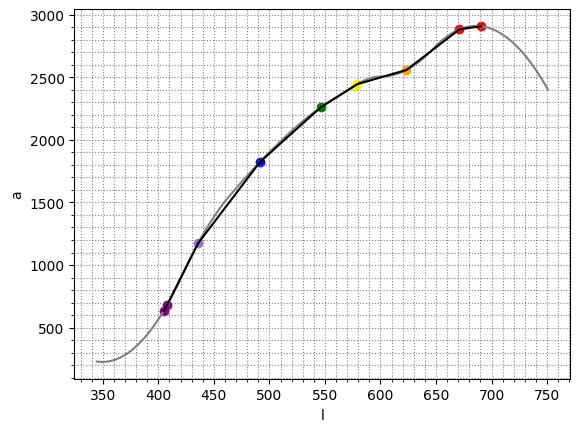

In [ ]:
plt.minorticks_on()
plt.grid(True, which='both')
plt.grid(which='both', color='gray', linestyle=':')

l = np.array([404.7, 407.8, 435.8, 491.6, 546.0, 576.9, 579.0, 623.4, 671.1, 690.7])
a = np.array([633, 680, 1174, 1824, 2258, 2432, 2444, 2558, 2882, 2907])

xnew = np.linspace(l.min() - 60, l.max() + 60, 200)
spline = make_interp_spline(l, a, k = 2)
y_smooth = spline(xnew)

plt.plot(xnew, y_smooth, color="grey")
plt.plot(l, a, color="black")
plt.xlabel("l")
plt.ylabel("a")
plt.scatter(404.7, 633, color="purple")
plt.scatter(407.8, 680, color="purple")
plt.scatter(435.8, 1174, color="mediumpurple")
plt.scatter(491.6, 1824, color="blue")
plt.scatter(546.0, 2258, color="green")
plt.scatter(576.9, 2432, color="yellow")
plt.scatter(579.0, 2444, color="yellow")
plt.scatter(623.4, 2558, color="orange")
plt.scatter(671.1, 2882, color="red")
plt.scatter(690.7, 2907, color="red")
plt.show()

In [ ]:
l = np.array([404.7, 407.8, 435.8, 491.6, 546.0, 576.9, 579.0, 623.4, 671.1, 690.7])
a = np.array([633, 680, 1174, 1824, 2258, 2432, 2444, 2558, 2882, 2907])

# Создаем градуировочную кривую
spline = interp1d(a, l, kind='cubic')  # используем кубическую интерполяцию

angles_known = np.array([2706, 1784, 1535])

# Интерполируем длины волн для известных углов
wavelengths_interpolated = spline(angles_known)

# Допустимая погрешность
angle_error = 50 # хз сколько ставить

# Оценка погрешностей длин волн через численное дифференцирование
wavelengths_plus = spline(angles_known + angle_error)
wavelengths_minus = spline(angles_known - angle_error)
wavelengths_error = (wavelengths_plus - wavelengths_minus) / 2

for i, color in enumerate(['Красная', 'Голубая', 'Фиолетовая']):
    print(f"{color} линия: Длина волны = {wavelengths_interpolated[i]:.2f} нм, Погрешность ≈ ±{wavelengths_error[i]:.2f} нм")

Красная линия: Длина волны = 633.27 нм, Погрешность ≈ ±-1.29 нм
Голубая линия: Длина волны = 487.62 нм, Погрешность ≈ ±4.95 нм
Фиолетовая линия: Длина волны = 464.00 нм, Погрешность ≈ ±4.48 нм


In [ ]:
# Теоретические значения по формуле Бальмера
R = 1.097e7  # Постоянная Ридберга в м^-1
n_values = np.arange(3, 6) # n>2 для водорода
theoretical_wavelengths = [1 / (R * (1/4 - 1/n**2)) * 1e9 for n in n_values]

print("Теоретические длины волн: ", theoretical_wavelengths)

Теоретические длины волн:  [656.3354603463993, 486.1744150714068, 434.084299170899]


In [ ]:
# Переводим в сантиметры и Рассчитываем волновые числа
wavenumbers = 1 / wavelengths_interpolated
print(f"Волновые числа: {np.round(wavenumbers, 5)}")

Волновые числа: [0.00158 0.00205 0.00216]


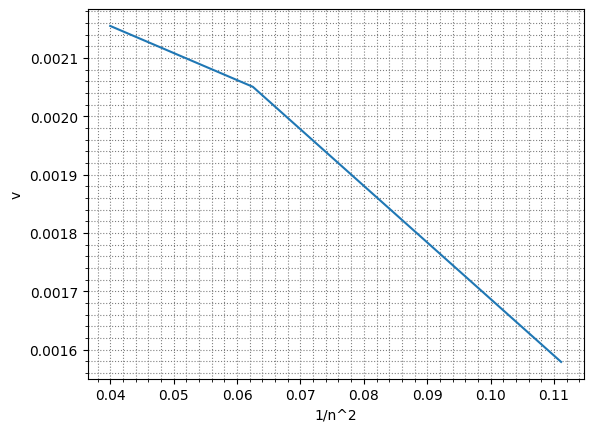

In [ ]:
plt.minorticks_on()
plt.grid(True, which='both')
plt.grid(which='both', color='gray', linestyle=':')
plt.xlabel("1/n^2")
plt.ylabel("v")
v = np.array(wavenumbers)
n = np.array([1/9, 1/16, 1/25])
plt.plot(n, v)

In [ ]:
# угловой коэффициент для пункта 4: беру две крайние точки и считаю наклон прямой между ними
k = (l[-1] - l[0]) / (a[-1] - a[0])

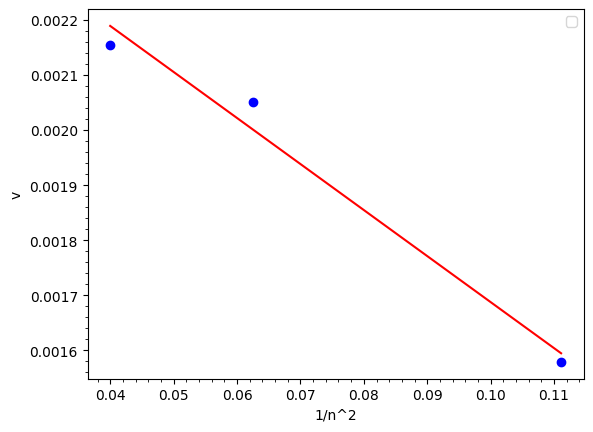

Точка пересечения с осью ординат: v = 0.002523431289258417


In [ ]:
from scipy import stats

n = np.array([1/9, 1/16, 1/25])

# Линейная аппроксимация
k, b, _, _, _ = stats.linregress(n, v)

plt.minorticks_on()
# plt.grid(True, which='both')
# plt.grid(which='both', color='gray', linestyle=':')

plt.xlabel("1/n^2")
plt.ylabel("v")

plt.plot(n, v, "bo")  # Точки
plt.plot(n, k * n + b, 'r-')

plt.legend()
plt.show()

# Точка пересечения когда x = 0, v = b
print(f"Точка пересечения с осью ординат: v = {b}")